## Введение. Математика

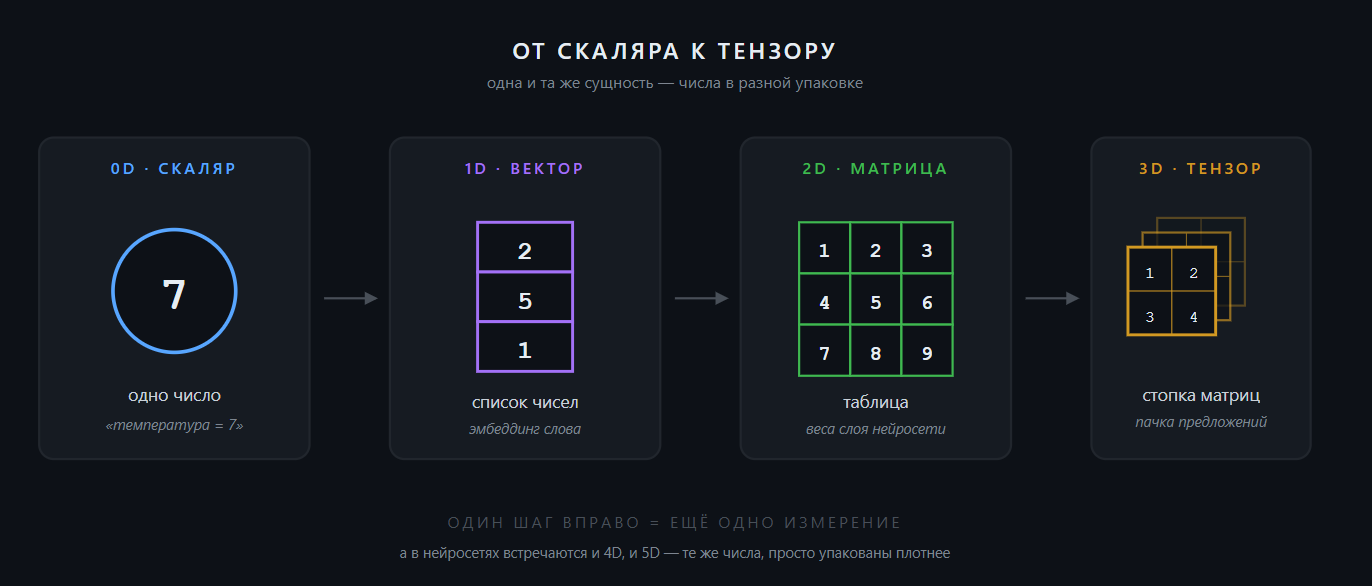

**Скаляр** - это одно-единственное число. Никаких списков, никаких таблиц. Просто 5, или -3.14, или 0.001

1. *Loss (Потеря)*: Одно число, показывающее, насколько модель ошиблась в предсказании. Чем меньше, тем лучше.
2. *Learning Rate (Скорость обучения)*: Одно число (например, 0.001), которое определяет, насколько «смело» модель меняет свои знания после каждой ошибки.
3. *Вероятность*: На выходе модель часто выдает скаляр от 0 до 1 (например, вероятность того, что следующее слово будет «кот»).

**Вектор** - это просто список чисел, записанных в строчку или в столбик. Порядок чисел важен! Программисты обычно называют такие структуры массивами или списками.

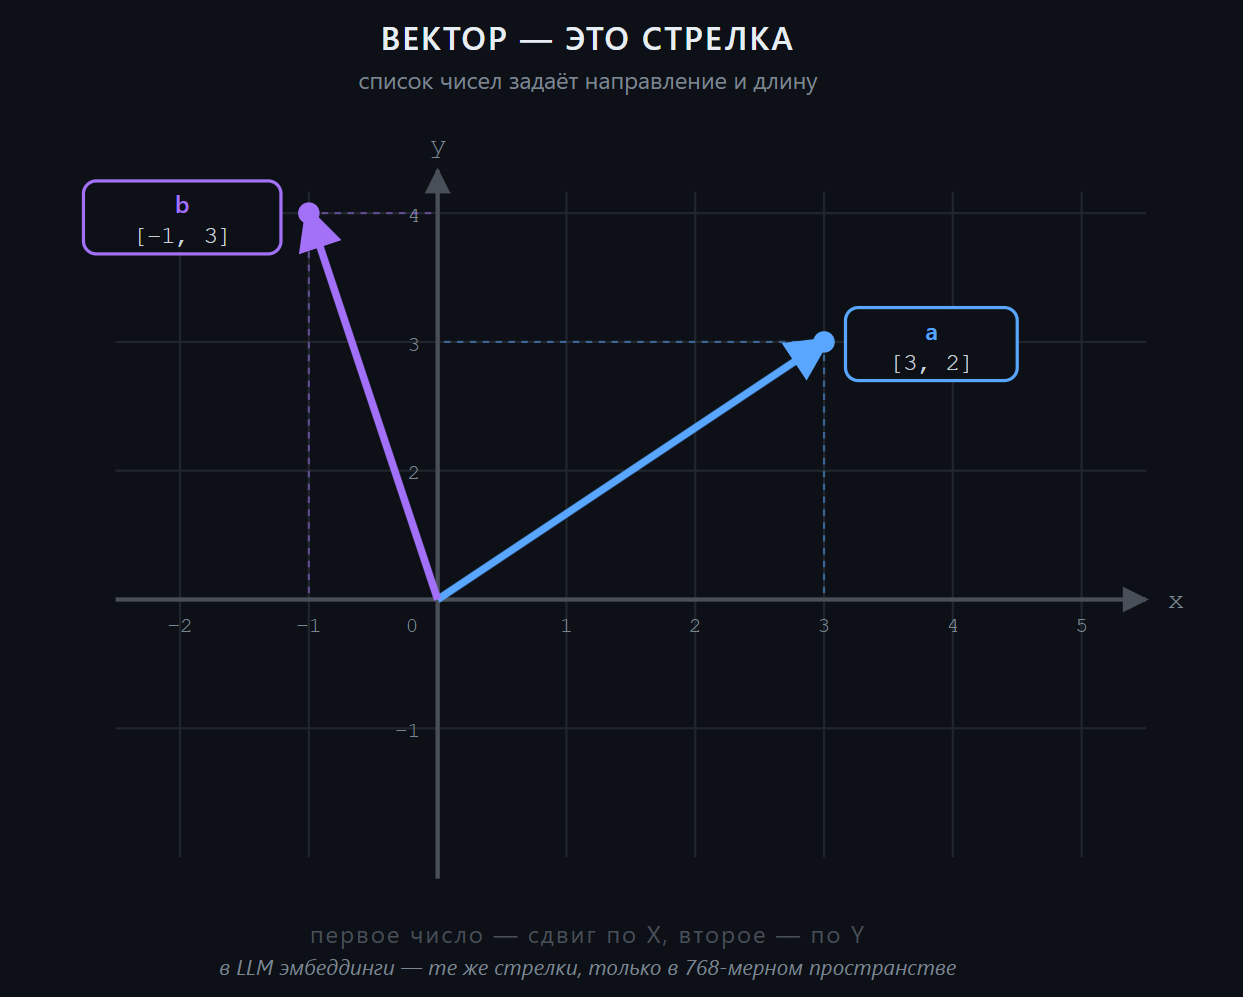

Операции определяются аналогично операциям над скалярами -- только поэлементно.

**Скалярное произведение (Dot Product)**: Умножаем числа по позициям, а потом СКЛАДЫВАЕМ все результаты. Получается ОДНО число (скаляр)!

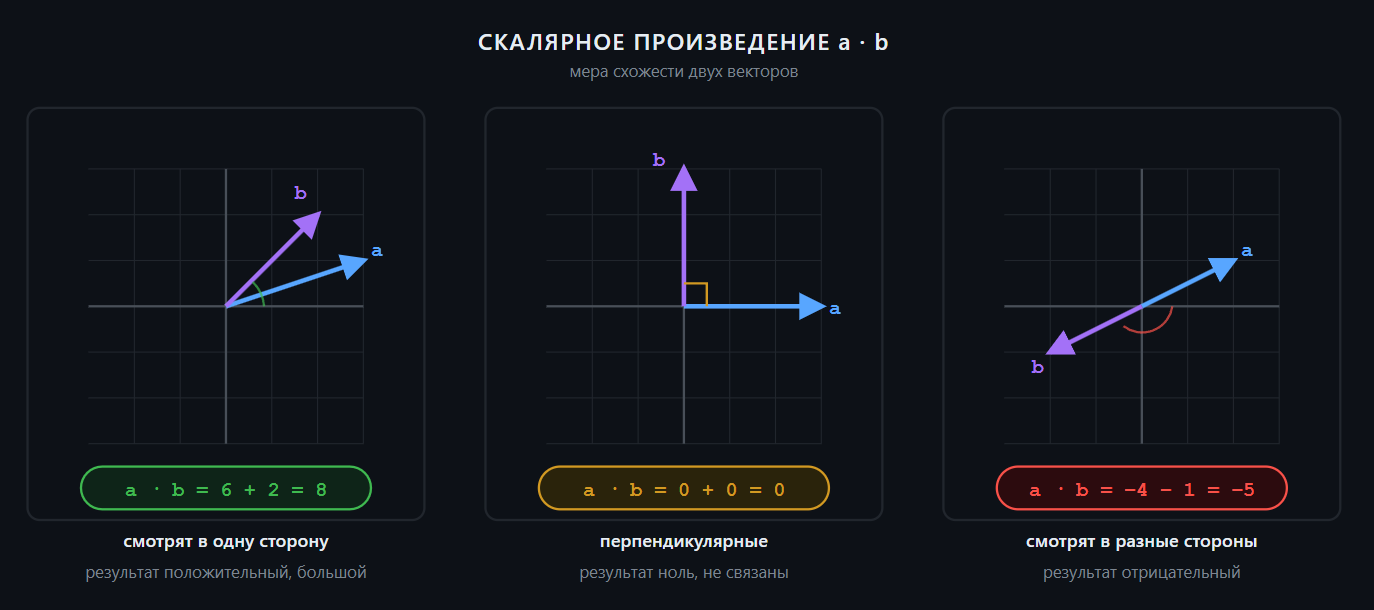

**Эмбеддинг (Embedding)**: Каждое слово превращается в вектор. Например, слово «король» может выглядеть как `[0.1, 0.9, ..., 0.3]`. Это «паспорт смысла» слова.

### L2-нормализация вектора

Шаг 1: квадрат каждого элемента
`квадраты = [0.8², (-0.2)², 0.5², 0.1²] = [0.64, 0.04, 0.25, 0.01]`

Шаг 2: сумма квадратов
`сумма = 0.64 + 0.04 + 0.25 + 0.01 = 0.94`

Шаг 3: корень из суммы
`norm = √0.94 ≈ 0.97`

Шаг 4: делим каждый элемент на norm
`нормализованный = [0.8/0.97, -0.2/0.97, 0.5/0.97, 0.1/0.97]
нормализованный ≈ [0.825, -0.206, 0.515, 0.103]`

**Матрица** - это прямоугольная таблица чисел. У неё есть строки (горизонтально) и столбцы (вертикально).

**Тензор** - Обобщение всего вышеперечисленного. Многомерный массив чисел. В ML (PyTorch/NumPy): Это просто «контейнер» для чисел с определенной формой (shape).

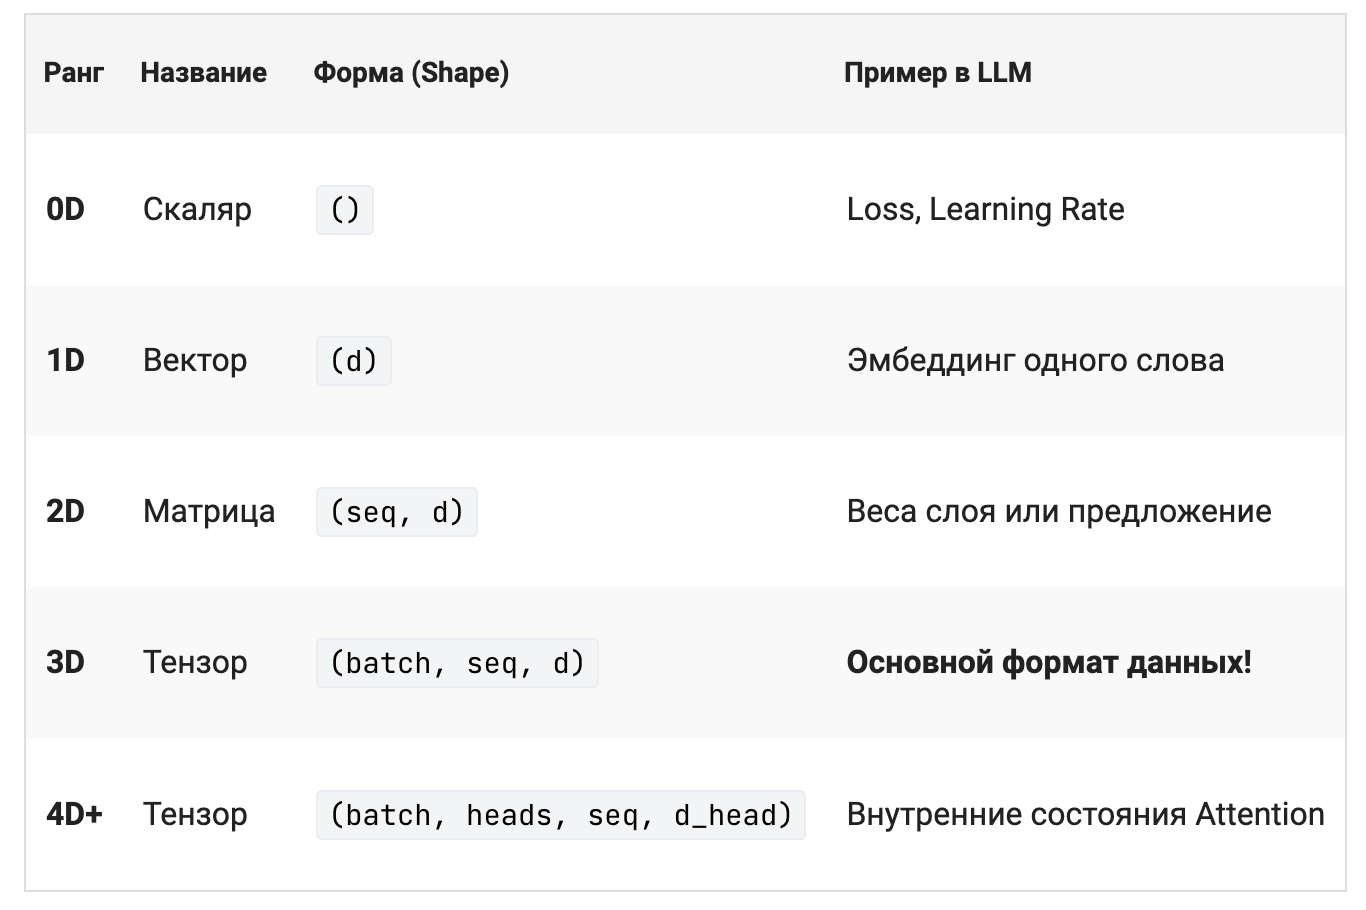

## Вероятности

Первоначальные оценки в языковых моделях называются **логиты (logits)**.

Рассмотрим пример с жюри, которое ставит баллы участникам:

* «Николай» - 12 баллов
* «Антон» - 11 баллов
* «Федор» - -3 балла
 *«Юрий» - 4 балла

Нам, людям, победитель уже более-менее понятен, но это ещё не вероятности. А для модели это просто «насколько она тянется к этому варианту».

И тут есть две проблемы:

Баллы могут быть отрицательными, а нам на выходе нужны неотрицательные вероятности.
Сумма баллов может быть какой угодно, а вероятности должны в сумме давать ровно 1. Вдобавок очень большие логиты вызывают численное переполнение экспоненты, поэтому на практике из логитов заранее вычитают максимум.
Нам нужно превратить эти баллы в "правильные" вероятности, у которых этих проблем нет.
И вот тут появляется главный герой - **Softmax**

**Softmax** превращает баллы в "правильные" вероятности

$$p_i = \large\frac{e^{x_i}}{\sum_j e^{x_j}}$$

* $x_i$ -  логит (балл) варианта $i$

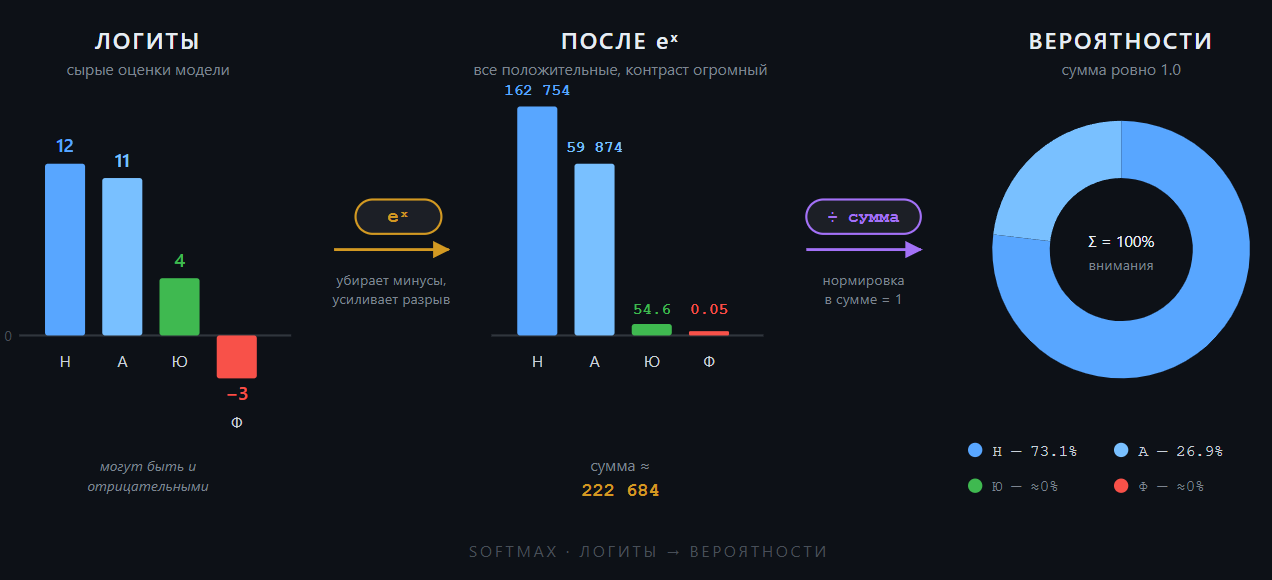

## Температура

Вы наверняка слышали про параметр **«температура» (temperature)**. И, скорее всего, знаете: если его менять, модель либо начинает много выдумывать, либо отвечает слишком однообразно.

А что, если мы хотим управлять распределением вероятностей? Уменьшим разницу между ними - модель чаще пробует менее вероятные варианты. Увеличим - почти всегда берёт лидера. Как раз для этого и нужна температура.

$$softmax(x_i, T)= \large\frac{e^{x_i/T}}{\sum_j e^{x_j/T}}$$

Когда $T>1$, логиты делятся на число больше единицы - их абсолютные значения уменьшаются, экспоненты становятся ближе друг к другу, распределение выравнивается. Модель чаще выбирает НЕ-лидеров, генерация становится разнообразнее. При очень больших $T (T → ∞$) распределение стремится к равномерному, и тогда модель действительно выбирает почти случайно.

Когда $T<1$, логиты делятся на число меньше единицы - они увеличиваются. Разрывы между ними становятся еще больше, модель чаще всего выбирает самый вероятный токен. При $T → 0$ генерация становится полностью детерминированной.

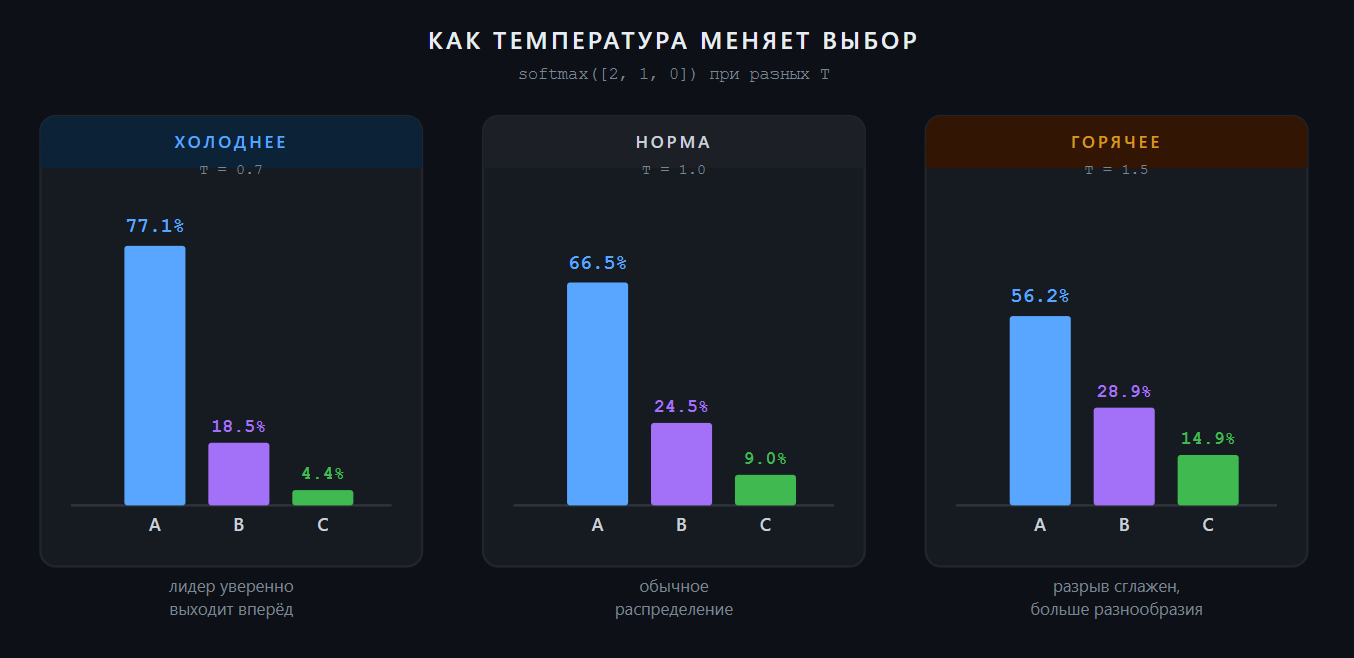

Мы видим, температура не меняет порядок слов - A остаётся самым вероятным, C - наименее. Но она меняет степень уверенности, с которой модель придерживается этого порядка. Таким образом, мы получаем удобный и простой инструмент для управления тем, какой будет наша модель при генерации.

## Градиентный спуск

Мы стоим на склоне, вокруг туман, карты нет.
Но мы можем нащупать, куда земля наклонена сильнее.

* если под ногами круто вниз → туда шагать выгодно
* если почти ровно → шаги дают мало эффекта


Обучение - это процесс:

1. модель сделала предсказание,
2. мы сравнили с правильным ответом,
3. получили «насколько плохо» (ошибка, loss),
4. и теперь надо понять: какие ручки крутить и в какую сторону, чтобы ошибка стала меньше.


### Формула градиентного спуска:

$$w_{new} = w_{old} - \eta \cdot \frac{dL}{dw}$$

* $L$ - ошибка
* $\eta$ - шаг обучения